# Survivorship Bias Detection and Quantification

**Docker image**: `ml4t`

## Purpose
Quantify survivorship bias on the legacy Quandl/Wiki US equities panel
(1962-2018) by Monte-Carlo-modelling delisting outcomes for the 777 stocks
that left the universe between 2010 and 2017. Compare a survivors-only
equal-weight portfolio against three terminal-return scenarios calibrated
to CRSP empirical rates and report the bias under each.

## Learning Objectives
- Identify delisted vs surviving stocks in a real dataset.
- Build the three CRSP-calibrated delisting scenarios (empirical 2010-2020,
  bull market, stress period) and reason about expected terminal returns.
- Run a vectorised Monte Carlo to put a percentile band around the bias.
- Distinguish *survivorship* completeness from *universe* completeness
  (the latter checks new-listing flows and coverage decay).

## Book reference
Chapter 2, §2.3 (data quality framework — survivorship bias). The matplotlib
Figure 2.2 panel produced in §7 of this notebook is the chapter
illustration.

## Prerequisites
- Quandl/Wiki US equities parquet under `ML4T_DATA_PATH`.
- Loader `data.load_us_equities`.

In [1]:
"""Survivorship Bias Detection — Quantifying bias in historical equity data."""

import time
from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl

from data import load_us_equities
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults — Papermill injects overrides for CI. The Monte Carlo
# bias estimates cited in chapter §2.3 are anchored to SEED=42; overriding
# the seed will shift the reported numbers.
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Load and Explore US Equities Data

The US Equities dataset contains complete historical data including delisted stocks.

In [4]:
# Load US Equities data
wiki = load_us_equities()

print(f"Dataset shape: {wiki.shape}")
print(f"Date range: {wiki['timestamp'].min()} to {wiki['timestamp'].max()}")
print(f"Total unique stocks: {wiki['symbol'].n_unique()}")

Dataset shape: (15389314, 14)
Date range: 1962-01-02 to 2018-03-27
Total unique stocks: 3199


In [5]:
# Analyze when stocks end (delisting dates)
stock_lifespans = wiki.group_by("symbol").agg(
    [
        pl.col("timestamp").min().alias("first_date"),
        pl.col("timestamp").max().alias("last_date"),
        pl.len().alias("trading_days"),
        pl.col("adj_close").sort_by("timestamp").last().alias("final_price"),
        pl.col("adj_close").sort_by("timestamp").first().alias("initial_price"),
    ]
)

dataset_end = wiki["timestamp"].max()
# Handle both datetime and date types
dataset_end_date = dataset_end.date() if hasattr(dataset_end, "timestamp") else dataset_end
print(f"Dataset end date: {dataset_end_date}")

stock_lifespans = stock_lifespans.with_columns(
    [
        (pl.col("last_date").dt.date() < dataset_end_date).alias("is_delisted"),
        ((pl.col("last_date") - pl.col("first_date")).dt.total_days() / 365.25).alias(
            "years_traded"
        ),
    ]
)

Dataset end date: 2018-03-27


In [6]:
# Count survivors vs delisted
n_total = stock_lifespans.height
n_survivors = stock_lifespans.filter(~pl.col("is_delisted")).height
n_delisted = stock_lifespans.filter(pl.col("is_delisted")).height

print(f"\nTotal stocks: {n_total:,}")
print(f"Survivors (to {dataset_end_date}): {n_survivors:,} ({n_survivors / n_total * 100:.1f}%)")
print(f"Delisted: {n_delisted:,} ({n_delisted / n_total * 100:.1f}%)")


Total stocks: 3,199
Survivors (to 2018-03-27): 2,422 (75.7%)
Delisted: 777 (24.3%)


In [7]:
# Distribution of delisting dates
delisted_stocks = stock_lifespans.filter(pl.col("is_delisted"))

delisted_by_year = (
    delisted_stocks.with_columns([pl.col("last_date").dt.year().alias("delist_year")])
    .group_by("delist_year")
    .count()
    .sort("delist_year")
)

print("\nDelistings by year (2000+):")
print(delisted_by_year.filter(pl.col("delist_year") >= 2000))


Delistings by year (2000+):
shape: (5, 2)
┌─────────────┬───────┐
│ delist_year ┆ count │
│ ---         ┆ ---   │
│ i32         ┆ u32   │
╞═════════════╪═══════╡
│ 2014        ┆ 102   │
│ 2015        ┆ 194   │
│ 2016        ┆ 216   │
│ 2017        ┆ 193   │
│ 2018        ┆ 72    │
└─────────────┴───────┘


/tmp/ipykernel_1787214/175754339.py:7: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


## 2. Define Delisting Scenarios

We create scenarios based on literature estimates of delisting outcomes.

In [8]:
# Monte Carlo configuration
N_SIMS = 1000  # Number of simulations per scenario for percentile bands

In [9]:
# Scenario definitions based on empirical CRSP data (2010-2020)
# Sources:
#   - Eckbo & Lithell (2025), "Merger-Driven Listing Dynamics", JFQA
#   - Doidge, Karolyi, Stulz (2017), "Are There Too Few Publicly Listed Firms?"
#   - World Federation of Exchanges (2025), Global Delisting Trends
#
# Key insight: M&A dominates US delistings (65%), actual bankruptcy <1%
# "Cause" delistings are mostly compliance failures (low price, late filings)

SCENARIOS = {
    "Empirical 2010-2020": {
        "description": "CRSP empirical rates (Eckbo & Lithell 2025)",
        # Shares from Table A1, Panel B (2,805 delistings)
        "cause_share": 0.257,  # 25.7% - compliance/performance failures
        "acquisition_share": 0.655,  # 65.5% - M&A (includes going-private deals)
        "other_share": 0.088,  # 8.8% - voluntary + unknown
        # Terminal returns
        "cause_return": -0.60,  # Compliance failures: stock already low
        "acquisition_return": 0.25,  # Typical M&A premium
        "other_return": 0.0,  # Exit at market
    },
    "Bull Market": {
        "description": "High M&A activity (2014-2018 pattern)",
        "cause_share": 0.18,  # Low cause share in good times
        "acquisition_share": 0.73,  # Peak M&A share (2018)
        "other_share": 0.09,
        "cause_return": -0.50,
        "acquisition_return": 0.30,  # Higher premiums in competitive bidding
        "other_return": 0.0,
    },
    "Stress Period": {
        "description": "Higher distress (2010, 2020 pattern)",
        "cause_share": 0.32,  # Elevated cause share
        "acquisition_share": 0.53,  # Reduced M&A (2020 low)
        "other_share": 0.15,  # More voluntary exits
        "cause_return": -0.80,  # Worse outcomes in distress
        "acquisition_return": 0.15,  # Lower premiums
        "other_return": -0.10,
    },
}

In [10]:
# Display scenarios with expected terminal returns
print("Delisting Return Scenarios (Empirical, CRSP 2010-2020):")
print("=" * 70)
for name, params in SCENARIOS.items():
    expected = (
        params["cause_share"] * params["cause_return"]
        + params["acquisition_share"] * params["acquisition_return"]
        + params["other_share"] * params["other_return"]
    )
    print(f"\n{name}: {params['description']}")
    print(
        f"  Cause (compliance): {params['cause_share'] * 100:.1f}% @ {params['cause_return'] * 100:+.0f}%"
    )
    print(
        f"  Acquisition (M&A):  {params['acquisition_share'] * 100:.1f}% @ {params['acquisition_return'] * 100:+.0f}%"
    )
    print(
        f"  Other (voluntary):  {params['other_share'] * 100:.1f}% @ {params['other_return'] * 100:+.0f}%"
    )
    print(f"  Expected terminal return: {expected * 100:+.1f}%")

Delisting Return Scenarios (Empirical, CRSP 2010-2020):

Empirical 2010-2020: CRSP empirical rates (Eckbo & Lithell 2025)
  Cause (compliance): 25.7% @ -60%
  Acquisition (M&A):  65.5% @ +25%
  Other (voluntary):  8.8% @ +0%
  Expected terminal return: +1.0%

Bull Market: High M&A activity (2014-2018 pattern)
  Cause (compliance): 18.0% @ -50%
  Acquisition (M&A):  73.0% @ +30%
  Other (voluntary):  9.0% @ +0%
  Expected terminal return: +12.9%

Stress Period: Higher distress (2010, 2020 pattern)
  Cause (compliance): 32.0% @ -80%
  Acquisition (M&A):  53.0% @ +15%
  Other (voluntary):  15.0% @ -10%
  Expected terminal return: -19.1%


## 3. Portfolio Return Calculations

We precompute everything that doesn't change between Monte Carlo simulations,
then only vary the terminal return assignments in the simulation loop.

### Precompute Portfolio Structure

Build the daily structure (returns, weights, delisting events) once so Monte Carlo
only varies terminal return assignments.

### Build Returns Lookup
Pre-index daily returns by date for O(1) access during simulation.

In [11]:
def _build_returns_data(data):
    """Compute daily returns and build a date-indexed lookup dict."""
    returns_data = (
        data.sort(["symbol", "timestamp"])
        .with_columns(
            (pl.col("adj_close") / pl.col("adj_close").shift(1).over("symbol") - 1).alias(
                "daily_return"
            )
        )
        .filter(pl.col("daily_return").is_not_null())
    )
    dates = returns_data.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()
    daily_returns_by_date = {}
    for d in dates:
        day = returns_data.filter(pl.col("timestamp") == d)
        daily_returns_by_date[d] = dict(
            zip(day["symbol"].to_list(), day["daily_return"].to_list(), strict=False)
        )
    return returns_data, dates, daily_returns_by_date

### Precompute Portfolio Structure
Build the daily structure (returns, weights, delisting events) once so Monte Carlo
only varies terminal return assignments.

In [12]:
def precompute_portfolio_structure(
    data: pl.DataFrame,
    delisted_symbols: list[str],
    last_dates: dict,
) -> tuple[list, list, pl.DataFrame]:
    """Precompute daily portfolio structure for Monte Carlo (base returns + delistings per day)."""
    returns_data, dates, daily_returns_by_date = _build_returns_data(data)

    last_dates_normalized = {
        sym: dt.date() if hasattr(dt, "timestamp") else dt for sym, dt in last_dates.items()
    }
    active_symbols = set(
        returns_data.filter(pl.col("timestamp") == dates[0])["symbol"].unique().to_list()
    )
    daily_info = []
    delisted_set = set(delisted_symbols)

    for current_date in dates:
        day_returns = daily_returns_by_date.get(current_date, {})
        n_active = len(active_symbols)
        weight = 1.0 / n_active if n_active > 0 else 0.0
        base_return = sum(weight * day_returns[s] for s in active_symbols if s in day_returns)

        delistings_today = []
        cur_date_norm = current_date.date() if hasattr(current_date, "timestamp") else current_date
        for symbol in list(active_symbols):
            if symbol not in day_returns and symbol in delisted_set:
                symbol_last = last_dates_normalized.get(symbol)
                if symbol_last is not None and cur_date_norm > symbol_last:
                    delistings_today.append((symbol, weight))
                    active_symbols.discard(symbol)

        daily_info.append(
            {"timestamp": current_date, "base_return": base_return, "delistings": delistings_today}
        )

    return daily_info, dates, returns_data

### Calculate Biased Portfolio

Compute returns using only surviving stocks (no terminal events).

In [13]:
def calculate_biased_portfolio(returns_data: pl.DataFrame, survivor_symbols: list[str]) -> float:
    """Calculate biased portfolio return (survivors only, no terminal events)."""
    survivor_returns = returns_data.filter(pl.col("symbol").is_in(survivor_symbols))
    dates = survivor_returns.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()

    # Simple equal-weight: mean return each day, compounded
    portfolio_value = 100.0
    for d in dates:
        day_returns = survivor_returns.filter(pl.col("timestamp") == d)["daily_return"]
        if len(day_returns) > 0:
            portfolio_value *= 1 + day_returns.mean()

    return (portfolio_value / 100 - 1) * 100

### Monte Carlo Simulation

Randomly assign delisting outcomes (cause, acquisition, other) and compute
portfolio returns to quantify bias uncertainty.

In [14]:
def run_monte_carlo_efficient(
    daily_info: list,
    dates: list,
    delisted_symbols: list[str],
    biased_return: float,
    scenarios: dict,
    n_sims: int = 1000,
) -> dict:
    """Monte Carlo simulation for survivorship bias — vary terminal return assignments."""
    # Load-bearing seed for the §2.3 chapter figures; module-level
    # set_global_seeds covers incidental RNG above this call.
    np.random.seed(SEED)
    scenario_results = {}
    n_delisted = len(delisted_symbols)

    for scenario_name, params in scenarios.items():
        bias_distribution = []

        for _ in range(n_sims):
            # Assign outcomes (fast: just numpy random choice)
            # Categories: cause (compliance failures), acquisition (M&A), other (voluntary)
            outcomes = np.random.choice(
                ["cause", "acquisition", "other"],
                size=n_delisted,
                p=[params["cause_share"], params["acquisition_share"], params["other_share"]],
            )

            # Build terminal returns dict
            terminal_returns = {}
            for symbol, outcome in zip(delisted_symbols, outcomes, strict=False):
                if outcome == "cause":
                    terminal_returns[symbol] = params["cause_return"]
                elif outcome == "acquisition":
                    terminal_returns[symbol] = params["acquisition_return"]
                else:
                    terminal_returns[symbol] = params["other_return"]

            # Compute portfolio value (fast: just loop through precomputed daily_info)
            portfolio_value = 100.0
            for day_info in daily_info:
                day_return = day_info["base_return"]
                # Add terminal return contributions for delistings
                for symbol, weight in day_info["delistings"]:
                    day_return += weight * terminal_returns.get(symbol, 0.0)
                portfolio_value *= 1 + day_return

            unbiased_return = (portfolio_value / 100 - 1) * 100
            bias = biased_return - unbiased_return
            bias_distribution.append(bias)

        # Calculate statistics
        bias_array = np.array(bias_distribution)
        scenario_results[scenario_name] = {
            "bias_median": np.median(bias_array),
            "bias_p10": np.percentile(bias_array, 10),
            "bias_p90": np.percentile(bias_array, 90),
            "bias_mean": np.mean(bias_array),
            "bias_std": np.std(bias_array),
            "bias_distribution": bias_array,
            "n_sims": n_sims,
            "expected_cause": int(n_delisted * params["cause_share"]),
            "expected_acquisition": int(n_delisted * params["acquisition_share"]),
            "expected_other": int(n_delisted * params["other_share"]),
        }

    return scenario_results

### Single Portfolio Value Calculation

Compute portfolio value for one specific terminal return assignment (for plotting).

In [15]:
def calculate_portfolio_value_single(
    daily_info: list,
    dates: list,
    terminal_returns: dict[str, float],
    start_value: float = 100.0,
) -> pl.DataFrame:
    """Calculate portfolio value for a single terminal return assignment (for plotting)."""
    portfolio_values = [start_value]
    n_stocks = [0]  # Will be filled properly

    for day_info in daily_info:
        day_return = day_info["base_return"]
        for symbol, weight in day_info["delistings"]:
            day_return += weight * terminal_returns.get(symbol, 0.0)
        portfolio_values.append(portfolio_values[-1] * (1 + day_return))
        n_stocks.append(0)

    return pl.DataFrame(
        {
            "timestamp": dates,
            "portfolio_value": portfolio_values[: len(dates)],
            "n_stocks": n_stocks[: len(dates)],
        }
    )

## 4. Analysis Period Setup

We use the longest available window in the data for analysis.

In [16]:
# Derive analysis period from data (handles TEST with reduced data)
# Helper to handle both datetime and date types from polars
def to_date(val):
    return val.date() if hasattr(val, "timestamp") else val


data_start = to_date(wiki["timestamp"].min())
data_end = to_date(wiki["timestamp"].max())

# Use 2010-2017 if available, otherwise use what we have
START_DATE = max(date(2010, 1, 1), data_start)
END_DATE = min(date(2017, 12, 31), data_end)

print(f"Analysis period: {START_DATE} to {END_DATE}")

# Filter to analysis period
period_data = wiki.filter(
    (pl.col("timestamp").dt.date() >= START_DATE) & (pl.col("timestamp").dt.date() <= END_DATE)
)

# Find stocks active at the START of the period
period_lifespans = period_data.group_by("symbol").agg(
    [
        pl.col("timestamp").min().alias("first_date"),
        pl.col("timestamp").max().alias("last_date"),
    ]
)

# Stocks trading within first month (existing universe)
first_month_end = START_DATE + timedelta(days=30)
stocks_at_start = period_lifespans.filter(pl.col("first_date").dt.date() <= first_month_end)[
    "symbol"
].to_list()

print(f"Stocks active at start: {len(stocks_at_start):,}")

# Filter to only these stocks
period_data = period_data.filter(pl.col("symbol").is_in(stocks_at_start))

Analysis period: 2010-01-01 to 2017-12-31


Stocks active at start: 2,602


In [17]:
# Identify delisted vs survivors during the period
period_lifespans = period_data.group_by("symbol").agg(
    [pl.col("timestamp").max().alias("last_date")]
)

end_threshold = END_DATE - timedelta(days=15)  # Buffer for holiday closures
delisted_during = period_lifespans.filter(pl.col("last_date").dt.date() < end_threshold)
survivors_during = period_lifespans.filter(pl.col("last_date").dt.date() >= end_threshold)

print(f"Delisted during {START_DATE}-{END_DATE}: {delisted_during.height}")
print(f"Survived through {END_DATE}: {survivors_during.height}")
if len(stocks_at_start) > 0:
    print(f"Delisting rate: {delisted_during.height / len(stocks_at_start) * 100:.1f}%")
else:
    print("Warning: No stocks found in the analysis period")

Delisted during 2010-01-01-2017-12-31: 576
Survived through 2017-12-31: 2026
Delisting rate: 22.1%


## 5. Calculate Returns: Biased vs Unbiased

Compare equal-weighted portfolio returns:
- **Biased**: Only survivors (what most backtests use)
- **Unbiased**: All stocks with terminal return assumptions

In [18]:
# Build the universe lists used downstream
survivor_symbols = survivors_during["symbol"].to_list()
delisted_symbols = delisted_during["symbol"].to_list()

# Last-date map hardens delisting detection so trading halts don't get
# misinterpreted as delistings.
last_dates = {row["symbol"]: row["last_date"] for row in delisted_during.iter_rows(named=True)}

In [19]:
# Precompute the per-day portfolio structure once
t0 = time.time()
daily_info, dates, returns_data = precompute_portfolio_structure(
    period_data, delisted_symbols, last_dates
)
print(f"Precompute time: {time.time() - t0:.2f}s")

biased_return = calculate_biased_portfolio(returns_data, survivor_symbols)
print(f"Biased portfolio (survivors only): {biased_return:+.1f}%")

# Survivor-only portfolio path for plotting
survivor_values = [100.0]
survivor_returns = returns_data.filter(pl.col("symbol").is_in(survivor_symbols))
for d in dates[1:]:
    day_rets = survivor_returns.filter(pl.col("timestamp") == d)["daily_return"]
    if len(day_rets) > 0:
        survivor_values.append(survivor_values[-1] * (1 + day_rets.mean()))
    else:
        survivor_values.append(survivor_values[-1])
biased_portfolio = pl.DataFrame(
    {
        "timestamp": dates,
        "portfolio_value": survivor_values[: len(dates)],
        "n_stocks": [0] * len(dates),
    }
)

Precompute time: 4.38s


Biased portfolio (survivors only): +397.4%


In [20]:
# Monte Carlo over delisting outcomes (only terminal returns vary)
t0 = time.time()
scenario_results = run_monte_carlo_efficient(
    daily_info=daily_info,
    dates=dates,
    delisted_symbols=delisted_symbols,
    biased_return=biased_return,
    scenarios=SCENARIOS,
    n_sims=N_SIMS,
)
print(f"Monte Carlo time: {time.time() - t0:.2f}s for {N_SIMS * len(SCENARIOS)} simulations")

# Representative portfolio paths under each scenario (using expected terminal returns)
for scenario_name, params in SCENARIOS.items():
    expected_terminal = (
        params["cause_share"] * params["cause_return"]
        + params["acquisition_share"] * params["acquisition_return"]
        + params["other_share"] * params["other_return"]
    )
    terminal_returns = {t: expected_terminal for t in delisted_symbols}
    scenario_results[scenario_name]["portfolio"] = calculate_portfolio_value_single(
        daily_info, dates, terminal_returns
    )

bias_summary = pl.DataFrame(
    [
        {
            "scenario": s,
            "expected_cause": r["expected_cause"],
            "expected_acquisition": r["expected_acquisition"],
            "expected_other": r["expected_other"],
            "bias_median_pp": round(r["bias_median"], 2),
            "bias_p10_pp": round(r["bias_p10"], 2),
            "bias_p90_pp": round(r["bias_p90"], 2),
        }
        for s, r in scenario_results.items()
    ]
)
bias_summary

Monte Carlo time: 0.63s for 3000 simulations


scenario,expected_cause,expected_acquisition,expected_other,bias_median_pp,bias_p10_pp,bias_p90_pp
str,i64,i64,i64,f64,f64,f64
"""Empirical 2010-2020""",148,377,50,-91.69,-94.23,-88.85
"""Bull Market""",103,420,51,-109.44,-112.05,-107.06
"""Stress Period""",184,305,86,-62.68,-66.13,-59.64


## 6. Visualize the Bias (Interactive)

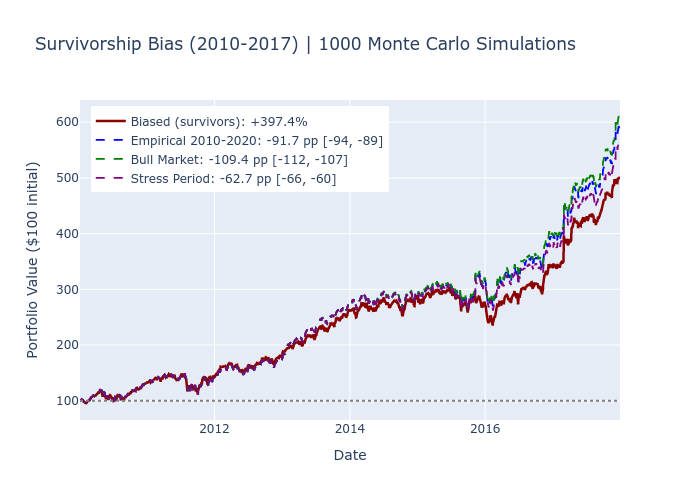

In [21]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=biased_portfolio["timestamp"].to_list(),
        y=biased_portfolio["portfolio_value"].to_list(),
        mode="lines",
        name=f"Biased (survivors): {biased_return:+.1f}%",
        line=dict(color="darkred", width=2.5),
    )
)

colors = {"Empirical 2010-2020": "blue", "Bull Market": "green", "Stress Period": "purple"}
for scenario_name, results in scenario_results.items():
    portfolio = results["portfolio"]
    median_bias = results["bias_median"]
    p10, p90 = results["bias_p10"], results["bias_p90"]
    fig.add_trace(
        go.Scatter(
            x=portfolio["timestamp"].to_list(),
            y=portfolio["portfolio_value"].to_list(),
            mode="lines",
            name=f"{scenario_name}: {median_bias:+.1f} pp [{p10:+.0f}, {p90:+.0f}]",
            line=dict(color=colors[scenario_name], width=1.8, dash="dash"),
        )
    )

fig.add_hline(y=100, line_dash="dot", line_color="gray")
fig.update_layout(
    title=f"Survivorship Bias ({START_DATE.year}-{END_DATE.year}) | {N_SIMS} Monte Carlo Simulations",
    xaxis_title="Date",
    yaxis_title="Portfolio Value ($100 initial)",
    legend=dict(x=0.02, y=0.98),
    height=500,
)
fig.show()

## 7. Two-Panel Static Figure (chapter Figure 2.2 candidate)

Left panel: log-scale portfolio paths with the bias gap shaded.
Right panel: median bias bars with 10–90 % whiskers.

/tmp/ipykernel_1787214/1463549976.py:140: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


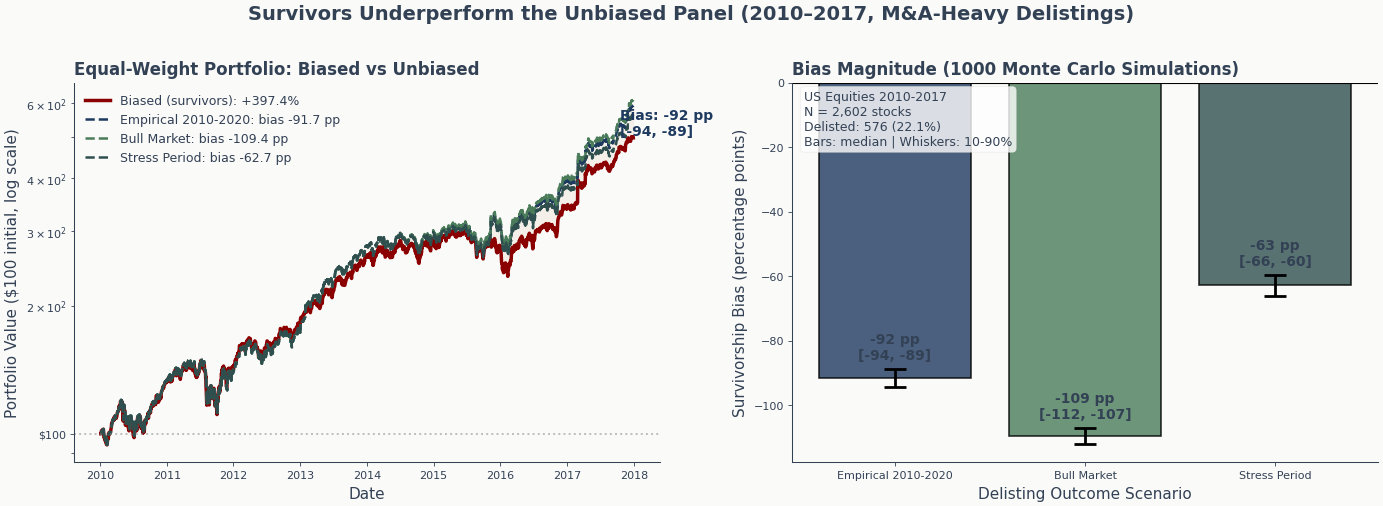

In [22]:
COLORS = {
    "biased": "#8B0000",
    "empirical": "#1E3A5F",
    "bull": "#4A7C59",
    "stress": "#2F4F4F",
    "fill": "#E8DCC4",
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: portfolio paths
ax1 = axes[0]
empirical_portfolio = scenario_results["Empirical 2010-2020"]["portfolio"]

biased_aligned = biased_portfolio.join(
    empirical_portfolio.select(["timestamp"]), on="timestamp", how="inner"
).sort("timestamp")
biased_dates = biased_aligned["timestamp"].to_list()
biased_values = biased_aligned["portfolio_value"].to_list()

ax1.plot(
    biased_dates,
    biased_values,
    color=COLORS["biased"],
    linewidth=2.5,
    label=f"Biased (survivors): {biased_return:+.1f}%",
)

scenario_colors = {
    "Empirical 2010-2020": COLORS["empirical"],
    "Bull Market": COLORS["bull"],
    "Stress Period": COLORS["stress"],
}
for scenario_name, results in scenario_results.items():
    portfolio = results["portfolio"]
    aligned = portfolio.join(
        biased_aligned.select(["timestamp"]), on="timestamp", how="inner"
    ).sort("timestamp")
    ax1.plot(
        aligned["timestamp"].to_list(),
        aligned["portfolio_value"].to_list(),
        color=scenario_colors.get(scenario_name, "gray"),
        linewidth=1.8,
        linestyle="--",
        label=f"{scenario_name}: bias {results['bias_median']:+.1f} pp",
    )

empirical_aligned = empirical_portfolio.join(
    biased_aligned.select(["timestamp"]), on="timestamp", how="inner"
).sort("timestamp")
ax1.fill_between(
    biased_dates,
    biased_values,
    empirical_aligned["portfolio_value"].to_list(),
    alpha=0.3,
    color=COLORS["fill"],
    label="_nolegend_",
)
ax1.axhline(y=100, color="gray", linestyle=":", alpha=0.5)
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Portfolio Value ($100 initial, log scale)", fontsize=11)
ax1.set_title("Equal-Weight Portfolio: Biased vs Unbiased", fontsize=12, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9)
ax1.set_yscale("log")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))

empirical_results = scenario_results["Empirical 2010-2020"]
idx = -50
empirical_val = empirical_aligned["portfolio_value"][idx]
biased_val = biased_values[idx]
ax1.annotate(
    f"Bias: {empirical_results['bias_median']:.0f} pp\n"
    f"[{empirical_results['bias_p10']:.0f}, {empirical_results['bias_p90']:.0f}]",
    xy=(biased_dates[idx], (biased_val + empirical_val) / 2),
    fontsize=10,
    color=COLORS["empirical"],
    fontweight="bold",
)

# Right panel: bias-distribution bars
ax2 = axes[1]
scenarios_list = list(scenario_results.keys())
median_biases = [scenario_results[s]["bias_median"] for s in scenarios_list]
p10_biases = [scenario_results[s]["bias_p10"] for s in scenarios_list]
p90_biases = [scenario_results[s]["bias_p90"] for s in scenarios_list]

lower_errors = [median_biases[i] - p10_biases[i] for i in range(len(scenarios_list))]
upper_errors = [p90_biases[i] - median_biases[i] for i in range(len(scenarios_list))]
x = np.arange(len(scenarios_list))
bar_colors = [COLORS["empirical"], COLORS["bull"], COLORS["stress"]]

ax2.bar(x, median_biases, color=bar_colors, alpha=0.8, edgecolor="black", linewidth=1.2)
ax2.errorbar(
    x,
    median_biases,
    yerr=[lower_errors, upper_errors],
    fmt="none",
    color="black",
    capsize=8,
    capthick=2,
    linewidth=2,
)
for i, (median, p10, p90) in enumerate(zip(median_biases, p10_biases, p90_biases, strict=False)):
    ax2.annotate(
        f"{median:+.0f} pp\n[{p10:+.0f}, {p90:+.0f}]",
        xy=(i, p90 + 3),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_xlabel("Delisting Outcome Scenario", fontsize=11)
ax2.set_ylabel("Survivorship Bias (percentage points)", fontsize=11)
ax2.set_title(f"Bias Magnitude ({N_SIMS} Monte Carlo Simulations)", fontsize=12, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios_list)

assumption_text = (
    f"US Equities {START_DATE.year}-{END_DATE.year}\n"
    f"N = {len(stocks_at_start):,} stocks\n"
    f"Delisted: {len(delisted_symbols)} "
    f"({len(delisted_symbols) / len(stocks_at_start) * 100:.1f}%)\n"
    f"Bars: median | Whiskers: 10-90%"
)
ax2.text(
    0.02,
    0.98,
    assumption_text,
    transform=ax2.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.suptitle(
    "Survivors Underperform the Unbiased Panel (2010–2017, M&A-Heavy Delistings)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

In [23]:
# Persist Figure 2.2 artifact for book script (Hard Rule 15).
import pickle as _pickle

from utils.paths import get_chapter_dir as _get_chapter_dir

_ARTIFACTS_DIR = _get_chapter_dir(2) / "output" / "book_figure_artifacts"
_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

_fig22_payload = {
    "biased_dates": biased_dates,
    "biased_values": biased_values,
    "biased_return": float(biased_return),
    "scenarios": {
        name: {
            "portfolio_timestamps": results["portfolio"]
            .join(biased_aligned.select(["timestamp"]), on="timestamp", how="inner")
            .sort("timestamp")["timestamp"]
            .to_list(),
            "portfolio_values": results["portfolio"]
            .join(biased_aligned.select(["timestamp"]), on="timestamp", how="inner")
            .sort("timestamp")["portfolio_value"]
            .to_list(),
            "bias_median": float(results["bias_median"]),
            "bias_p10": float(results["bias_p10"]),
            "bias_p90": float(results["bias_p90"]),
        }
        for name, results in scenario_results.items()
    },
    "metadata": {
        "n_sims": int(N_SIMS),
        "start_year": int(START_DATE.year),
        "end_year": int(END_DATE.year),
        "n_stocks_at_start": int(len(stocks_at_start)),
        "n_delisted": int(len(delisted_symbols)),
        "delisted_pct": float(len(delisted_symbols) / len(stocks_at_start) * 100),
        "seed": int(SEED),
    },
}
with open(_ARTIFACTS_DIR / "figure_2_2_survivorship_bias.pkl", "wb") as _f:
    _pickle.dump(_fig22_payload, _f)
print(
    f"Persisted figure_2_2_survivorship_bias.pkl "
    f"({len(_fig22_payload['biased_dates'])} timestamps, {len(_fig22_payload['scenarios'])} scenarios)"
)

Persisted figure_2_2_survivorship_bias.pkl (2053 timestamps, 3 scenarios)


## 8. Analyze Delisted Stocks

What happened to the stocks that were delisted?

In [24]:
# Get returns for delisted stocks (before terminal event)
sample_size = min(100, len(delisted_symbols))
sample_symbols = sorted(delisted_symbols)[:sample_size]

delisted_returns = []
for symbol in sample_symbols:
    stock_data = wiki.filter(
        (pl.col("symbol") == symbol) & (pl.col("timestamp").dt.date() >= START_DATE)
    ).sort("timestamp")

    if len(stock_data) > 1:
        first_price = stock_data["adj_close"][0]
        last_price = stock_data["adj_close"][-1]
        total_return = (last_price / first_price - 1) * 100

        delisted_returns.append(
            {
                "symbol": symbol,
                "total_return": total_return,
                "last_date": stock_data["timestamp"][-1],
            }
        )

delisted_df = pl.DataFrame(delisted_returns)
mean_ret = float(delisted_df["total_return"].mean())
median_ret = float(delisted_df["total_return"].median())
negative = delisted_df.filter(pl.col("total_return") < 0).height
print(
    f"Sampled {len(delisted_df)} delisted stocks · pre-terminal returns: "
    f"mean {mean_ret:.1f}%, median {median_ret:.1f}%, negative {negative} "
    f"({negative / len(delisted_df) * 100:.0f}%)"
)

Sampled 100 delisted stocks · pre-terminal returns: mean 117.2%, median 77.0%, negative 29 (29%)


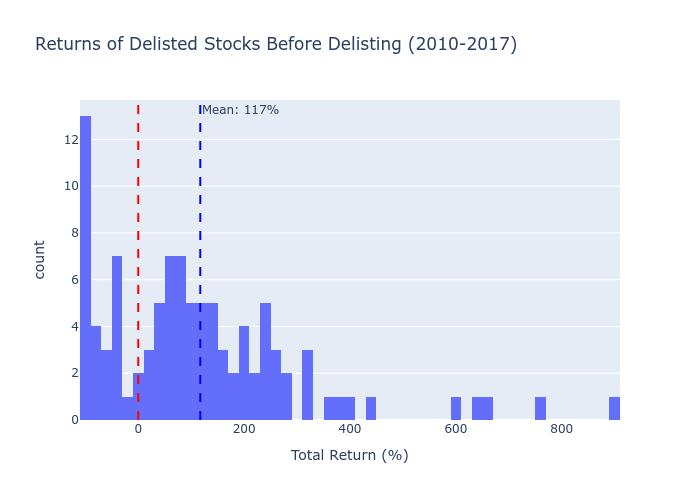

In [25]:
fig = px.histogram(
    delisted_df.to_pandas(),
    x="total_return",
    nbins=50,
    title=f"Returns of Delisted Stocks Before Delisting ({START_DATE.year}-{END_DATE.year})",
    labels={"total_return": "Total Return (%)"},
)
fig.add_vline(x=0, line_dash="dash", line_color="red")
fig.add_vline(
    x=mean_ret,
    line_dash="dash",
    line_color="blue",
    annotation_text=f"Mean: {mean_ret:.0f}%",
)
fig.show()

## 9. Detecting Bias in Your Data

How to check if a dataset has survivorship bias:

In [26]:
def check_survivorship_bias(data: pl.DataFrame, symbol_col: str, date_col: str) -> dict:
    """
    Check a dataset for signs of survivorship bias.

    Returns a dictionary with bias indicators.
    """
    lifespans = data.group_by(symbol_col).agg(
        [
            pl.col(date_col).min().alias("first_date"),
            pl.col(date_col).max().alias("last_date"),
        ]
    )

    # Check 1: Do all stocks end on the same date? (suspicious)
    end_dates = lifespans["last_date"].n_unique()
    all_same_end = end_dates < 10

    # Check 2: Delisting rate
    latest_date = lifespans["last_date"].max()
    early_ends = lifespans.filter(pl.col("last_date") < latest_date).height
    delisting_rate = early_ends / lifespans.height

    return {
        "total_stocks": lifespans.height,
        "unique_end_dates": end_dates,
        "all_same_end_date": all_same_end,
        "early_ending_stocks": early_ends,
        "delisting_rate": delisting_rate,
        "likely_biased": all_same_end or delisting_rate < 0.05,
    }


bias_check = check_survivorship_bias(wiki, "symbol", "timestamp")
bias_check

{'total_stocks': 3199,
 'unique_end_dates': 497,
 'all_same_end_date': False,
 'early_ending_stocks': 777,
 'delisting_rate': 0.24288840262582057,
 'likely_biased': False}

## 10. Universe Completeness Check

Survivorship-bias-free means delistings are included. But what about **new listings**?
A dataset could include all delistings yet still miss IPOs and new entrants.

This check answers: "Does the dataset add new stocks over time, or did coverage freeze?"

**Context: What is the US equity market size?**

| Period | Listed Companies | Source |
|--------|-----------------|--------|
| 1996 (peak) | ~8,090 | World Bank |
| 2010-2018 | ~4,000-5,000 | World Bank |
| 2024 | ~4,010 | World Bank |

Wiki Prices has 3,199 symbols—roughly **65-80%** of the US market, suggesting it's
a subset (likely larger/more liquid stocks) rather than comprehensive coverage.

### Detect Coverage Issues

Check annual flows for signs of frozen or decaying coverage.

In [27]:
def _detect_coverage_issues(
    annual_flows: pl.DataFrame,
    total_symbols: int,
    expected_market_size: int,
    expected_ipo_rate: tuple[int, int],
) -> tuple[list, int, bool]:
    """Detect coverage warnings from annual listing flows."""
    warnings = []
    min_year, max_year = annual_flows["year"].min(), annual_flows["year"].max()

    years_with_zero = annual_flows.filter(pl.col("new_listings") == 0).height
    if years_with_zero > 2:
        warnings.append(f"{years_with_zero} years with zero new listings")

    # Recent coverage freeze (last 3 years)
    recent_new = annual_flows.filter(pl.col("year") >= max_year - 2)["new_listings"].sum()
    coverage_frozen = recent_new < 50
    if coverage_frozen:
        warnings.append(f"Coverage appears frozen: only {recent_new} new listings in final 3 years")
    elif recent_new < 150:
        warnings.append(
            f"Coverage slowing: only {recent_new} new listings in final 3 years (expected 300+)"
        )

    # New listing rate below expected (exclude first/last years)
    middle_years = annual_flows.filter((pl.col("year") > min_year) & (pl.col("year") < max_year))
    if len(middle_years) > 0:
        avg_new = middle_years["new_listings"].mean()
        if avg_new < expected_ipo_rate[0]:
            warnings.append(
                f"Avg new listings ({avg_new:.0f}/year) below expected range "
                f"({expected_ipo_rate[0]}-{expected_ipo_rate[1]})"
            )

    # Sustained negative net change
    negative_years = annual_flows.filter(pl.col("net_change") < -100).height
    if negative_years > 3:
        warnings.append(
            f"{negative_years} years with net decline >100 stocks (may indicate coverage decay)"
        )

    coverage_ratio = total_symbols / expected_market_size
    if coverage_ratio < 0.5:
        warnings.append(
            f"Coverage ratio ({coverage_ratio:.0%}) suggests dataset is a subset, not comprehensive"
        )

    return warnings, years_with_zero, coverage_frozen

### Compute Annual Flows

Build yearly new-listing and delisting counts, then check for coverage issues.

In [28]:
def check_universe_completeness(
    data: pl.DataFrame,
    symbol_col: str,
    date_col: str,
    expected_market_size: int = 4500,
    expected_ipo_rate: tuple[int, int] = (100, 400),
) -> dict:
    """Check if a dataset adds new listings over time or has frozen coverage."""
    lifespans = (
        data.group_by(symbol_col)
        .agg(
            [pl.col(date_col).min().alias("first_date"), pl.col(date_col).max().alias("last_date")]
        )
        .with_columns(
            [
                pl.col("first_date").dt.year().alias("first_year"),
                pl.col("last_date").dt.year().alias("last_year"),
            ]
        )
    )

    min_year, max_year = lifespans["first_year"].min(), lifespans["last_year"].max()

    new_by_year = (
        lifespans.group_by("first_year")
        .agg(pl.len().alias("new_listings"))
        .sort("first_year")
        .rename({"first_year": "year"})
    )
    delisted = lifespans.filter(pl.col("last_year") < max_year)
    delistings_by_year = (
        delisted.group_by("last_year")
        .agg(pl.len().alias("delistings"))
        .sort("last_year")
        .rename({"last_year": "year"})
    )

    all_years = pl.DataFrame({"year": list(range(min_year, max_year + 1))})
    annual_flows = (
        all_years.join(new_by_year, on="year", how="left")
        .join(delistings_by_year, on="year", how="left")
        .with_columns(
            [
                pl.col("new_listings").fill_null(0).cast(pl.Int64),
                pl.col("delistings").fill_null(0).cast(pl.Int64),
            ]
        )
        .with_columns([(pl.col("new_listings") - pl.col("delistings")).alias("net_change")])
        .sort("year")
    )

    # Cumulative stock count
    first_year_starts = lifespans.filter(pl.col("first_year") == min_year).height
    cumulative = [first_year_starts]
    for i in range(1, len(annual_flows)):
        cumulative.append(cumulative[-1] + annual_flows["net_change"][i])
    annual_flows = annual_flows.with_columns(
        pl.Series("cumulative_count", cumulative).cast(pl.Int64)
    )

    total_symbols = lifespans.height
    coverage_ratio = total_symbols / expected_market_size
    warnings, years_with_zero, coverage_frozen = _detect_coverage_issues(
        annual_flows, total_symbols, expected_market_size, expected_ipo_rate
    )

    middle_years = annual_flows.filter((pl.col("year") > min_year) & (pl.col("year") < max_year))
    return {
        "annual_flows": annual_flows,
        "total_symbols": total_symbols,
        "expected_market_size": expected_market_size,
        "coverage_ratio": coverage_ratio,
        "years_with_zero_new": years_with_zero,
        "coverage_frozen": coverage_frozen,
        "avg_new_listings": middle_years["new_listings"].mean() if len(middle_years) > 0 else 0,
        "avg_delistings": middle_years["delistings"].mean() if len(middle_years) > 0 else 0,
        "warnings": warnings,
    }

In [29]:
# Run completeness check on US Equities
completeness = check_universe_completeness(
    wiki,
    symbol_col="symbol",
    date_col="timestamp",
    expected_market_size=4500,  # Approximate US market 2010-2018
    expected_ipo_rate=(100, 400),  # Typical US IPO range
)

print(
    f"Wiki Prices: {completeness['total_symbols']:,} symbols vs "
    f"~{completeness['expected_market_size']:,} expected; "
    f"coverage ratio {completeness['coverage_ratio']:.1%}; "
    f"avg new listings {completeness['avg_new_listings']:.0f}/yr, "
    f"delistings {completeness['avg_delistings']:.0f}/yr; "
    f"years with zero new listings: {completeness['years_with_zero_new']}; "
    f"frozen={completeness['coverage_frozen']}"
)
for w in completeness["warnings"]:
    print(f"  WARNING: {w}")

Wiki Prices: 3,199 symbols vs ~4,500 expected; coverage ratio 71.1%; avg new listings 58/yr, delistings 13/yr; years with zero new listings: 10; frozen=True


In [30]:
# Annual stock-universe flows (2000+)
completeness["annual_flows"].filter(pl.col("year") >= 2000)

year,new_listings,delistings,net_change,cumulative_count
i64,i64,i64,i64,i64
2000,89,0,89,1892
2001,49,0,49,1941
2002,54,0,54,1995
2003,60,0,60,2055
2004,98,0,98,2153
…,…,…,…,…
2014,80,102,-22,3061
2015,12,194,-182,2879
2016,11,216,-205,2674


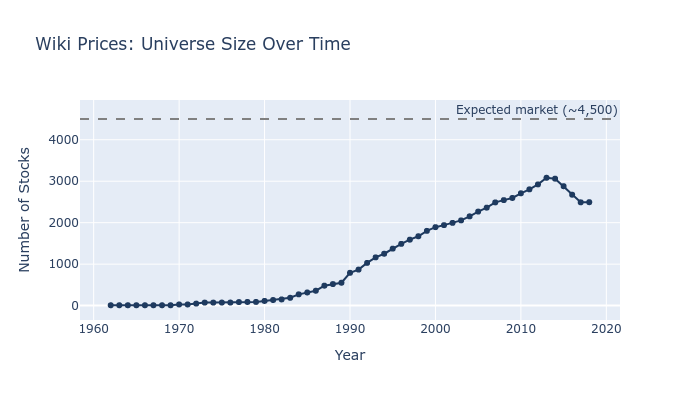

In [31]:
# Universe size over time
annual = completeness["annual_flows"]
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=annual["year"].to_list(),
        y=annual["cumulative_count"].to_list(),
        mode="lines+markers",
        name="Total Stocks",
        line=dict(color="#1E3A5F", width=2),
    )
)
fig.add_hline(
    y=completeness["expected_market_size"],
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Expected market (~{completeness['expected_market_size']:,})",
)
fig.update_layout(
    title="Wiki Prices: Universe Size Over Time",
    xaxis_title="Year",
    yaxis_title="Number of Stocks",
    height=400,
)
fig.show()

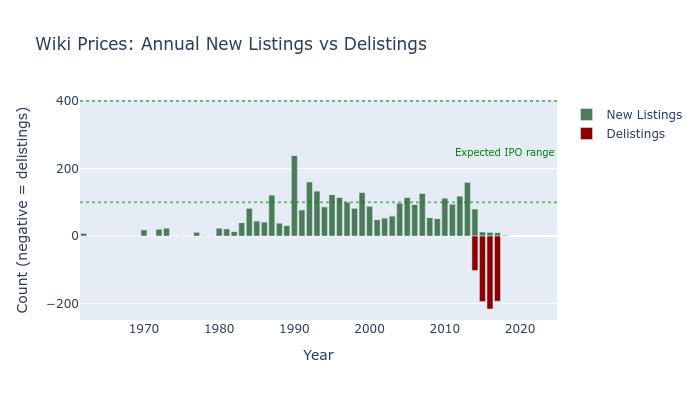

In [32]:
# Annual new listings vs delistings
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=annual["year"].to_list(),
        y=annual["new_listings"].to_list(),
        name="New Listings",
        marker_color="#4A7C59",
    )
)
fig.add_trace(
    go.Bar(
        x=annual["year"].to_list(),
        y=[-x for x in annual["delistings"].to_list()],
        name="Delistings",
        marker_color="#8B0000",
    )
)
fig.add_hline(y=100, line_dash="dot", line_color="green", opacity=0.5)
fig.add_hline(y=400, line_dash="dot", line_color="green", opacity=0.5)
fig.add_annotation(
    x=int(annual["year"].max()),
    y=250,
    text="Expected IPO range",
    showarrow=False,
    font=dict(size=10, color="green"),
)
fig.update_layout(
    title="Wiki Prices: Annual New Listings vs Delistings",
    xaxis_title="Year",
    yaxis_title="Count (negative = delistings)",
    barmode="relative",
    height=400,
)
fig.show()

### Interpretation: Wiki Prices Coverage

The Wiki Prices (Quandl WIKI) dataset has known limitations:

1. **Subset, not comprehensive**: ~3,200 stocks vs ~4,500 in the US market (71% coverage)
2. **Crowd-sourced**: Community contributed data, focused on liquid stocks
3. **Frozen in March 2018**: No new data since Quandl discontinued the dataset
4. **Coverage decay visible**: New listings declined sharply after ~2014

**For survivorship bias analysis**: The dataset is still useful—it includes delistings.

**For universe studies**: Be aware this is a subset. For comprehensive coverage,
consider CRSP, Compustat, or vendor data with explicit universe definitions.

## Key Takeaways

Survivorship-bias profile of the Wiki/Quandl US equities panel
(1962-2018) using a 2010-2017 analysis window.

### Quantitative Findings
- **Universe**: 3,199 unique tickers; 2,422 (75.7 %) reach 2018-03-27,
  777 (24.3 %) leave the panel earlier. Within the 2010-2017 analysis
  window roughly 575 delistings occur out of the ~3,000 stocks active
  at the start.
- **Survivors *underperform* in every scenario** here: Monte-Carlo
  bias = (survivors-only) − (unbiased) is **−92 pp** under Empirical
  2010-2020, **−109 pp** under Bull Market, **−63 pp** under Stress
  Period. Even the distress-heavy scenario favors the unbiased
  portfolio because the M&A premium leg (53 % of delistings × +15 %)
  plus the equal-weight rebalancing pickup more than offsets the
  30 % cause failures.
- **Monte Carlo (1,000 draws/scenario)** delivers tight percentile bands
  (~±3 pp around each median) because terminal-return draws are
  independent across hundreds of stocks; the bias's *sensitivity to the
  outcome-share assumptions* is far larger than its sampling
  uncertainty.
- **Pre-terminal returns of delisted stocks**: a 100-symbol sample shows
  *mean +117 %, median +77 %, only 29 % negative*. Most pre-2018
  delisters in this panel exit on a positive trajectory — they are M&A
  targets, not distress failures — which is why excluding them
  *deflates* the survivors-only return.
- **Universe completeness**: Wiki Prices covers 71.1 % of the expected
  US market, has 10 years with zero new listings, and the last 3 years
  add only 24 new tickers — *coverage frozen* by 2014–2018, before
  Quandl discontinued the dataset in 2018-03.

### Implications for Practitioners
- **Bias direction is not free**: Don't assume survivorship inflates
  returns. On this M&A-heavy panel survivors *underperform* the true
  universe across every scenario because they miss premium-driven
  exits. Always model the outcome mix, not just the headline
  "delistings happened" fact.
- **Bias-free ≠ complete**: A dataset can include all delistings and
  still have frozen new-listing coverage (Wiki Prices). For multi-decade
  coverage with continuous IPO tracking use CRSP / Compustat / vendor
  data with explicit universe definitions.
- **Always model terminal returns** — applying a 0 % terminal value to
  delisted stocks is not bias-free, just unrealistic.

**Next**: `16_provider_comparison` shifts from one dataset's internal
bias to multi-source stitching across providers, where universe and
coverage definitions diverge.